# RoBERTa-base (A Robustly Optimized BERT Pretraining Approach)

Reference paper: https://arxiv.org/pdf/1907.11692

Model: https://huggingface.co/FacebookAI/roberta-base

Dataset: https://huggingface.co/datasets/dair-ai/emotion



## Installazioni

In [36]:
pip install transformers datasets torch scikit-learn matplotlib pandas numpy evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00


## Connessione a Google Drive

In [2]:
#CONNETTI DRIVE

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Caricamento e analisi del dataset

In [1]:
from datasets import load_dataset
import pandas as pd

# Caricamento dataset
dataset = load_dataset("dair-ai/emotion")

# Esplorazione
print("Struttura del dataset:")
print(dataset)

#Visualizza primi 5 esempi
print("\nEsempi dataset:")
train_df = pd.DataFrame(dataset['train'])
print(train_df.head())

#Labels
labels = dataset['train'].features['label'].names
print(f"Emozioni: {labels}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Struttura del dataset:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Esempi dataset:
                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3
Emozioni: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


### Bilanciamento delle classi


Bilanciamento delle classi:
label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64


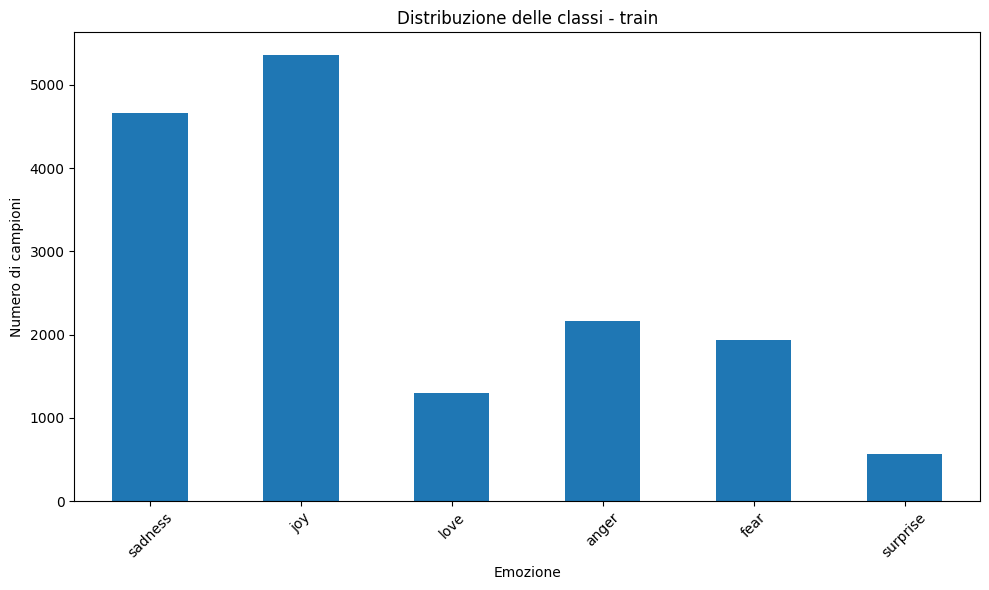

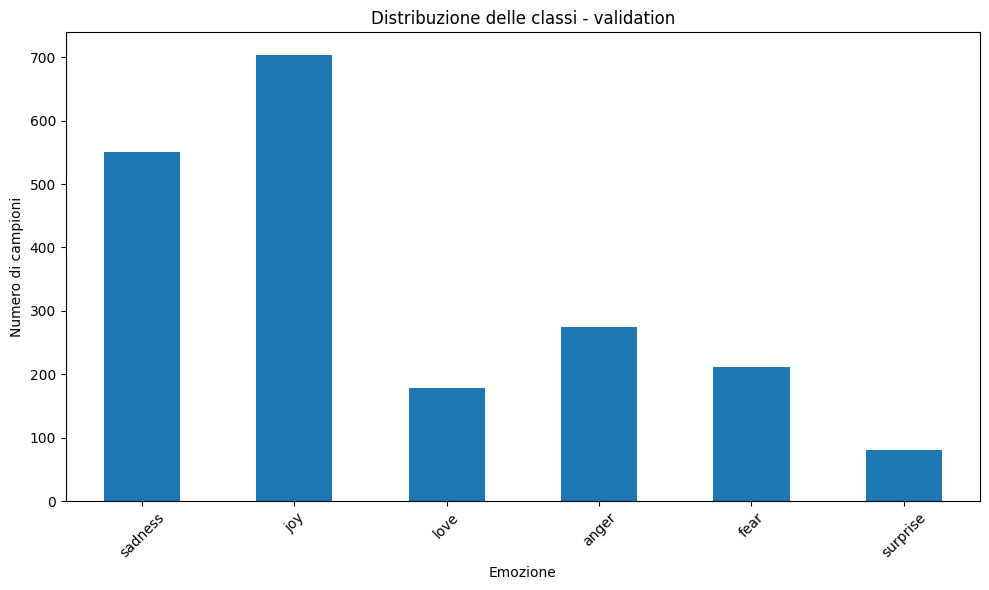

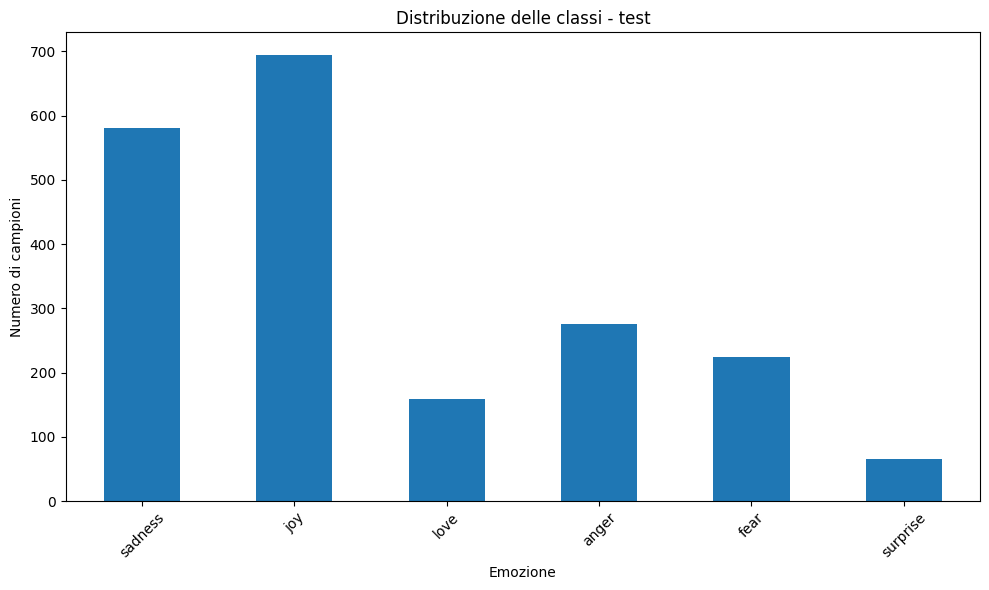

In [ ]:
import matplotlib.pyplot as plt

#Visualizza bilanciamento delle classi
print("\nBilanciamento delle classi:")
print(train_df['label'].value_counts())

# Distribuzione delle classi
def plot_class_distribution(dataset, split_name):

    labels = dataset[split_name]['label']
    label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

    plt.figure(figsize=(10, 6))
    pd.Series(labels).value_counts().sort_index().plot(kind='bar')
    plt.xticks(range(6), label_names, rotation=45)
    plt.title(f'Distribuzione delle classi - {split_name}')
    plt.ylabel('Numero di campioni')
    plt.xlabel('Emozione')
    plt.tight_layout()
    plt.savefig(f'class_distribution_{split_name}.png', dpi=300)
    plt.show()

plot_class_distribution(dataset, 'train')
plot_class_distribution(dataset, 'validation')
plot_class_distribution(dataset, 'test')

#In tutte e tre le split, la classe 'joy' risulta essere la più frequente rispetto a 'surprise', di conseguenza si verifica uno sbilanciamento


### Lunghezza dei testi

Lunghezza media: 19.17 parole
Lunghezza mediana: 17.00 parole
Min: 2, Max: 66


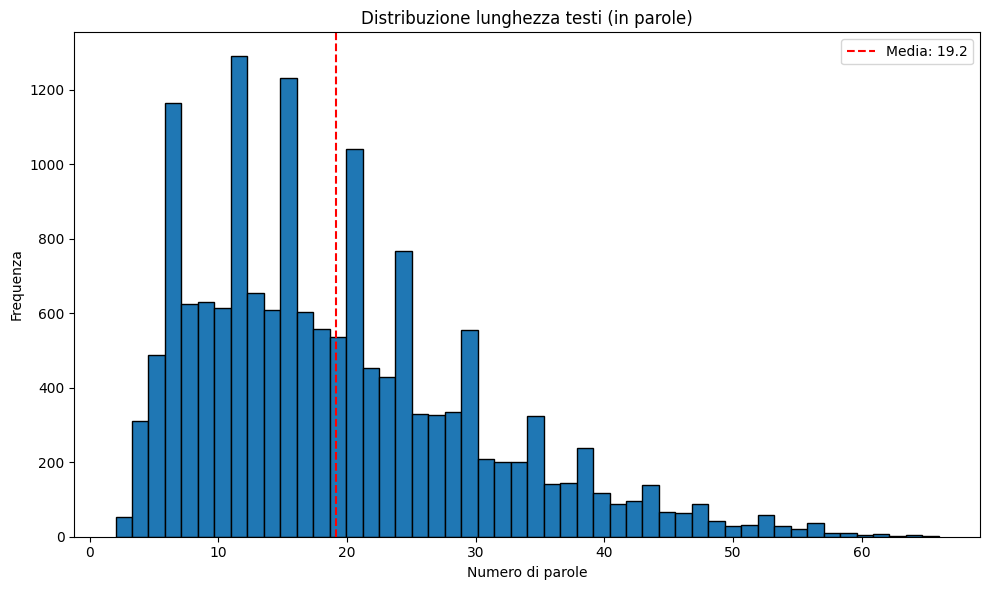

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Lunghezza dei testi da utilizzare in seguito per ICL
def analyze_text_length(dataset):
    lengths = [len(text.split()) for text in dataset['train']['text']]

    print(f"Lunghezza media: {np.mean(lengths):.2f} parole")
    print(f"Lunghezza mediana: {np.median(lengths):.2f} parole")
    print(f"Min: {min(lengths)}, Max: {max(lengths)}")

    plt.figure(figsize=(10, 6))
    plt.hist(lengths, bins=50, edgecolor='black')
    plt.title('Distribuzione lunghezza testi (in parole)')
    plt.xlabel('Numero di parole')
    plt.ylabel('Frequenza')
    plt.axvline(np.mean(lengths), color='red', linestyle='--', label=f'Media: {np.mean(lengths):.1f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('text_length_distribution.png', dpi=300)
    plt.show()

analyze_text_length(dataset)

## Prepazione del dataset

In [41]:

from transformers import AutoTokenizer

# Caricamento tokenizer RoBERTa
tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")

# Funzione di tokenizzazione
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,        # Troncamento se > 128 token come descritto nel paper
        max_length=128,
    )

# Applicazione tokenizzazione
tokenized_datasets = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]  # Rimuovi colonna testo originale
)

# Rinomina label in labels (standard HuggingFace)
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Imposta formato PyTorch
tokenized_datasets.set_format("torch")

print("Dataset tokenizzato:")
print(tokenized_datasets['train'][0])


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset tokenizzato:
{'labels': tensor(0), 'input_ids': tensor([    0,   118, 46405,   619, 32386,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1])}


## Metriche di valutazione

In [42]:
import evaluate

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    acc = accuracy.compute(predictions=predictions, references=labels)
    f1_macro = f1.compute(predictions=predictions, references=labels, average="macro")

    return {"accuracy": acc["accuracy"], "f1": f1_macro["f1"]}

## Modello base

### Caricamento del modello base

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Mapping delle label
id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}

# Caricamento modello RoBERTa-base
model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Valutazione del modello base

In [ ]:
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import numpy as np

# VALUTAZIONE DEL MODELLO BASE NON ALLINEATO (classification head casuale)

# Prepara i batch con padding dinamico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Configurazione per la valutazione
training_args = TrainingArguments(
    output_dir="./results/base_model",      # Dove salvare
    per_device_eval_batch_size=32,        # 32 esempi per batch
    report_to="none"                      # Non loggare su wandb/tensorboard
)

# Crea il trainer
trainer = Trainer(
    model=model,                           # Modello da valutare
    args=training_args,                    # Configurazione
    data_collator=data_collator,           # Come preparare i batch
    eval_dataset=tokenized_datasets["validation"],  # Dataset di default
    processing_class=tokenizer,            # Tokenizer per salvare il modello
    compute_metrics=compute_metrics        # Come calcolare le metriche
)

# Valuta sul test set
base_model_metrics = trainer.evaluate(tokenized_datasets["test"])

# Stampa risultati
print("VALUTAZIONE MODELLO BASE\n")
print(f"Accuracy: {base_model_metrics['eval_accuracy']:.4f}")
print(f"F1-Score: {base_model_metrics['eval_f1']:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


VALUTAZIONE MODELLO BASE

Accuracy: 0.2905
F1-Score: 0.0750


## Modello con classification head allineata

### Allineamento della classification head

In [ ]:
import itertools
import json
import os
from datetime import datetime
from transformers import EarlyStoppingCallback

# ALLINEAMENTO DELLA CLASSIFICATION HEAD

print("\n" + "="*60)
print("Classification Head Alignment")
print("="*60)

learning_rates = [1e-3, 1e-4, 1e-5]
batch_sizes = [16, 32]

best_accuracy = 0
best_f1 = 0
ch_alignment_best_params = {}
ch_alignment_results = []

total_combinations = len(learning_rates) * len(batch_sizes)
print(f"\nCombinazioni da testare: {total_combinations}")
print(f"Learning rates: {learning_rates}")
print(f"Batch sizes: {batch_sizes}")
print(f"Inizio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 60)

for idx, (lr, bs) in enumerate(itertools.product(learning_rates, batch_sizes), start=1):

    # Identificatore univoco per questa combinazione
    combo_id = f"lr{lr}_bs{bs}"

    print(f"\n{'='*60}")
    print(f"[{idx}/{total_combinations}] Test: LR={lr}, Batch={bs}")
    print(f"Timestamp: {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*60}")

    try:
        # Ricarica il modello base ogni volta
        model = AutoModelForSequenceClassification.from_pretrained(
            "FacebookAI/roberta-base",
            num_labels=6,
            id2label=id2label,
            label2id=label2id
        )

        # Congela il base model (RoBERTa)
        for param in model.base_model.parameters():
            param.requires_grad = False

        # Scongela solo la classification head
        for param in model.classifier.parameters():
            param.requires_grad = True

        # Verifica parametri da allenare
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f"Parametri trainabili: {trainable:,} ({100*trainable/total:.1f}%)")

        # Setta i parametri di training
        training_args_alignment = TrainingArguments(
            output_dir=f"./results/ch_alignment/{combo_id}",

            # Parametri di training
            num_train_epochs=3,                  # Poche epoche per allineare la head
            per_device_train_batch_size=bs,      # Batch size training
            per_device_eval_batch_size=bs,       # Batch size evaluation

            # Ottimizzazione
            learning_rate=lr,                  # LR alto (alleniamo solo la head)
            weight_decay=0.01,
            warmup_steps=0.1,                    # 10% warmup

            # Valutazione e salvataggio
            eval_strategy="epoch",               # Valuta ogni epoca
            save_strategy="epoch",
            save_total_limit=1,                  # Salva solo il miglior checkpoint
            load_best_model_at_end=False,
            metric_for_best_model="f1",

            # Logging
            logging_steps=50,
            report_to="none",

            fp16=True,

            # Seed per riproducibilità
            seed=42,
        )

        # Inizializzazione trainer
        trainer = Trainer(
            model=model,
            args=training_args_alignment,
            data_collator=data_collator,
            train_dataset=tokenized_datasets["train"],
            eval_dataset=tokenized_datasets["validation"],
            #processing_class=tokenizer,
            compute_metrics=compute_metrics,
        )

        # Training
        print("--- Inizio training ---")
        trainer.train()

        # Valutazione sul test set
        print("--- Valutazione su test set ---")
        eval_result = trainer.evaluate(tokenized_datasets["test"])

        # Prepara risultati
        result = {
            'id': combo_id,
            'lr': lr,
            'batch_size': bs,
            'accuracy': eval_result['eval_accuracy'],
            'f1': eval_result['eval_f1'],
            'loss': eval_result['eval_loss'],
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        # Salva risultati
        ch_alignment_results.append(result)

        print(f"\n Risultati test set: Acc={result['accuracy']:.4f}, F1={result['f1']:.4f}, Loss={result['loss']:.4f}")

        # Aggiorna e salva best model
        if result['f1'] > best_f1:
            best_f1 = result['f1']
            best_accuracy = result['accuracy']
            ch_alignment_best_params = result
            print(f"Nuovo BEST MODEL!")

        # Libera memoria GPU
        del model, trainer
        import torch
        torch.cuda.empty_cache()

        print(f"Memoria GPU liberata")

    except Exception as e:
        print(f"\nERRORE durante training di {combo_id}: {e}")
        continue

# RISULTATI FINALI

print("\n" + "="*60)
print("RISULTATI FINALI")
print("="*60)
print(f"Completato: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 60)

print(ch_alignment_best_params)
# Tabella ordinata per F1
print(f"\n{'LR':<12} {'Batch':<8} {'Accuracy':<12} {'F1':<12} {'Loss':<12}")
print("-" * 60)
for r in sorted(ch_alignment_results, key=lambda x: x['f1'], reverse=True):
    marker = "x" if r['id'] == ch_alignment_best_params['id'] else "  "
    print(f"{marker} {r['lr']:<10.0e} {r['batch_size']:<8} "
          f"{r['accuracy']:<12.4f} {r['f1']:<12.4f} {r['loss']:<12.4f}")




Classification Head Alignment

Combinazioni da testare: 6
Learning rates: [0.001, 0.0001, 1e-05]
Batch sizes: [16, 32]
Inizio: 2026-02-25 11:46:07
------------------------------------------------------------

[1/6] Test: LR=0.001, Batch=16
Timestamp: 11:46:08


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametri trainabili: 595,206 (0.5%)
Inizio training...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.444284,1.354052,0.483500,0.212996
2,1.320842,1.220066,0.559500,0.317174
3,1.270797,1.203306,0.577500,0.328735


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Valutazione su test set...



 Risultati test set: Acc=0.3475, F1=0.0860, Loss=1.5591
Memoria GPU liberata

RISULTATI FINALI
Completato: 2026-02-25 11:55:34
------------------------------------------------------------
{'id': 'lr0.001_bs16', 'lr': 0.001, 'batch_size': 16, 'accuracy': 0.5795, 'f1': 0.32496535018780226, 'loss': 1.1690441370010376, 'timestamp': '2026-02-25 11:48:09'}

LR           Batch    Accuracy     F1           Loss        
------------------------------------------------------------
x 1e-03      16       0.5795       0.3250       1.1690      
   1e-03      32       0.5680       0.3066       1.1988      
   1e-04      16       0.5145       0.2068       1.4603      
   1e-04      32       0.4965       0.1988       1.4972      
   1e-05      16       0.3475       0.0860       1.5543      
   1e-05      32       0.3475       0.0860       1.5591      


'print("\n" + "="*60)\nprint("MIGLIOR CONFIGURAZIONE:")\nprint("="*60)\nprint(f"Learning Rate: {ch_alignment_best_params[\'lr\']}")\nprint(f"Batch Size: {ch_alignment_best_params[\'batch_size\']}")\nprint(f"Accuracy: {ch_alignment_best_params[\'accuracy\']:.4f}")\nprint(f"F1 Score: {ch_alignment_best_params[\'f1\']:.4f}")\nprint(f"Loss: {ch_alignment_best_params[\'loss\']:.4f}")\nprint("="*60)'

## Modello base vs Modello allineato

In [ ]:
base_model_metrics = {
    'eval_f1': 0.0750,
    'eval_accuracy': 0.2905
}
aligned_metrics = {
    'eval_f1': 0.3250,
    'eval_accuracy': 0.5795
}

# Confronto modello base vs modello allineato
print("\n" + "="*60)
print("CONFRONTO MODELLO BASE vs MODELLO ALLINEATO:")
print("="*60)
print(f"{'Metrica':<15} {'Base':<12} {'Allineato':<12} {'Δ':<10}")
print("-"*60)
print(f"{'Accuracy':<15} {base_model_metrics['eval_accuracy']:<12.4f} {aligned_metrics['eval_accuracy']:<12.4f} {(aligned_metrics['eval_accuracy'] - base_model_metrics['eval_accuracy']):<10.4f}")
print(f"{'F1-Score':<15} {base_model_metrics['eval_f1']:<12.4f} {aligned_metrics['eval_f1']:<12.4f} {(aligned_metrics['eval_f1'] - base_model_metrics['eval_f1']):<10.4f}")
print("="*60)


CONFRONTO MODELLO BASE vs MODELLO ALLINEATO:
Metrica         Base         Allineato    Δ         
------------------------------------------------------------
Accuracy        0.2905       0.5795       0.2890    
F1-Score        0.0750       0.3250       0.2500    


## Full Fine-Tuning

### Fine-tuning e valutazione

In [ ]:
import itertools
import json
import os
from datetime import datetime
from transformers import EarlyStoppingCallback

# Crea cartelle per salvataggi
base_dir = '/content/drive/MyDrive/RoBERTa-base'
os.makedirs(base_dir, exist_ok=True)
os.makedirs(f'{base_dir}/checkpoints', exist_ok=True)

print(f"Salvataggi verranno salvati in: {base_dir}")

# --- FINE TUNING ---

print("\n" + "="*60)
print("FINE TUNING")
print("="*60)

# Parametri come definiti nel paper di riferimento
learning_rates = [1e-5, 2e-5, 3e-5]
batch_sizes = [16, 32]

# File per salvare progresso
progress_file = f'{base_dir}/progress.json'

# Carica progresso esistente (se disponibile)
if os.path.exists(progress_file):
    with open(progress_file, 'r') as f:
        completed_runs = json.load(f)
    print(f"Trovate {len(completed_runs)} combinazioni già completate\n")
    print(f"Riprendo da dove mi ero fermato...")
else:
    completed_runs = []

# Variabili per tracciare i risultati
best_accuracy = 0
best_f1 = 0
best_params = {}
all_results = []

total_combinations = len(learning_rates) * len(batch_sizes)
print(f"\nCombinazioni da testare: {total_combinations}")
print(f"Learning rates: {learning_rates}")
print(f"Batch sizes: {batch_sizes}")
print(f"Inizio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 60)

for idx, (lr, bs) in enumerate(itertools.product(learning_rates, batch_sizes), start=1):

    # Identificatore univoco per questa combinazione
    combo_id = f"lr{lr}_bs{bs}"

    # Controlla se già completato
    if combo_id in [r['id'] for r in completed_runs]:
        print(f"\n[{idx}/{total_combinations}] SKIP: {combo_id} (già completato)")
        result = next(r for r in completed_runs if r['id'] == combo_id)
        all_results.append(result)
        if result['f1'] > best_f1:
            best_f1 = result['f1']
            best_accuracy = result['accuracy']
            best_params = result
        continue

    print(f"\n{'='*60}")
    print(f"[{idx}/{total_combinations}] Test: LR={lr}, Batch={bs}")
    print(f"Timestamp: {datetime.now().strftime('%H:%M:%S')}")
    print(f"{'='*60}")

    try:
        # Ricarica il modello base ogni volta
        model = AutoModelForSequenceClassification.from_pretrained(
            "FacebookAI/roberta-base",
            num_labels=6,
            id2label=id2label,
            label2id=label2id
        )

        # Scongela tutto per ricalibrare il 100%
        for param in model.parameters():
            param.requires_grad = True

        # Verifica parametri da allenare
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model.parameters())
        print(f"Parametri trainabili: {trainable:,} ({100*trainable/total:.1f}%)")

        # Setta i parametri di training
        training_args = TrainingArguments(
            output_dir=f"{base_dir}/checkpoints/{combo_id}",
            eval_strategy="epoch",
            save_strategy="epoch",  # Salva checkpoint ogni epoca
            save_total_limit=1,     # Mantieni solo il migliore
            learning_rate=lr,
            per_device_train_batch_size=bs,
            per_device_eval_batch_size=bs,
            num_train_epochs=10, # Nel paper sono state utilizzate 10 epoch
            weight_decay=0.01,
            warmup_steps=0.1,
            report_to="none",
            load_best_model_at_end=False,  # Carica il migliore alla fine
            metric_for_best_model="f1",
            greater_is_better=True,
            fp16=True,
            logging_steps=50,
            seed=42,
        )

        # Inizializzazione trainer
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized_datasets["train"],
            eval_dataset=tokenized_datasets["validation"],
            compute_metrics=compute_metrics,
            data_collator=data_collator,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
        )

        # Training
        print("--- Inizio training ---")
        trainer.train()

        # Valutazione sul test set
        print("--- Valutazione su test set ---")
        eval_result = trainer.evaluate(tokenized_datasets["test"])

        # Prepara risultati
        result = {
            'id': combo_id,
            'lr': lr,
            'batch_size': bs,
            'accuracy': eval_result['eval_accuracy'],
            'f1': eval_result['eval_f1'],
            'loss': eval_result['eval_loss'],
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }

        # Salva risultati
        all_results.append(result)
        completed_runs.append(result)

        # Salva progresso su Drive (backup continuo)
        with open(progress_file, 'w') as f:
            json.dump(completed_runs, f, indent=2)

        print(f"\nRisultati test set: Acc={result['accuracy']:.4f}, F1={result['f1']:.4f}, Loss={result['loss']:.4f}")

        # Aggiorna e salva best model
        if result['f1'] > best_f1:
            best_f1 = result['f1']
            best_accuracy = result['accuracy']
            best_params = result

            # Salva il miglior modello su Drive
            best_model_path = f'{base_dir}/best_model'
            trainer.save_model(best_model_path)
            tokenizer.save_pretrained(best_model_path)

            print(f"Nuovo BEST MODEL salvato!")
            print(f"Path: {best_model_path}")

        # Libera memoria GPU
        del model, trainer
        import torch
        torch.cuda.empty_cache()

        print(f"Memoria GPU liberata")

    except Exception as e:
        print(f"\nERRORE durante training di {combo_id}: {e}")

        # Salva log errori
        error_log = f'{base_dir}/errors.log'
        with open(error_log, 'a') as f:
            f.write(f"{datetime.now()}: {combo_id} - {str(e)}\n")

        continue

# --- RISULTATI FINALI ---

print("\n" + "="*60)
print("RISULTATI FINALI")
print("="*60)
print(f"Completato: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("-" * 60)

# Tabella ordinata per F1
print(f"\n{'LR':<12} {'Batch':<8} {'Accuracy':<12} {'F1':<12} {'Loss':<12}")
print("-" * 60)
for r in sorted(all_results, key=lambda x: x['f1'], reverse=True):
    marker = "x" if r['id'] == best_params['id'] else "  "
    print(f"{marker} {r['lr']:<10.0e} {r['batch_size']:<8} "
          f"{r['accuracy']:<12.4f} {r['f1']:<12.4f} {r['loss']:<12.4f}")

print("\n" + "="*60)
print("MIGLIOR CONFIGURAZIONE:")
print("="*60)
print(f"Learning Rate: {best_params['lr']}")
print(f"Batch Size: {best_params['batch_size']}")
print(f"Accuracy: {best_params['accuracy']:.4f}")
print(f"F1 Score: {best_params['f1']:.4f}")
print(f"Loss: {best_params['loss']:.4f}")
print(f"\nModello salvato in: {base_dir}/best_model")
print("="*60)

# --- SALVA RISULTATI FINALI ---

# Salva summary completo
summary = {
    'experiment': 'RoBERTa Fine-Tuning',
    'completed_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_combinations': total_combinations,
    'best_params': best_params,
    'all_results': all_results,
    'search_space': {
        'learning_rates': learning_rates,
        'batch_sizes': batch_sizes
    }
}

with open(f'{base_dir}/final_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nRisultati completi salvati in: {base_dir}/final_results.json")


Salvataggi verranno salvati in: /content/drive/MyDrive/RoBERTa-base

FINE TUNING

Combinazioni da testare: 6
Learning rates: [1e-05, 2e-05, 3e-05]
Batch sizes: [16, 32]
Inizio: 2026-02-19 09:17:48
------------------------------------------------------------

[1/6] Test: LR=1e-05, Batch=16
Timestamp: 09:17:48


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parametri trainabili: 124,650,246 (100.0%)


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Valutazione su test set...



 Risultati test set: Acc=0.9290, F1=0.8828, Loss=0.1585
Memoria GPU liberata

RISULTATI FINALI
Completato: 2026-02-19 10:16:55
------------------------------------------------------------

LR           Batch    Accuracy     F1           Loss        
------------------------------------------------------------
x 2e-05      16       0.9310       0.8926       0.2222      
   1e-05      32       0.9260       0.8880       0.1813      
   2e-05      32       0.9275       0.8840       0.2075      
   3e-05      32       0.9290       0.8828       0.1585      
   3e-05      16       0.9230       0.8816       0.2626      
   1e-05      16       0.9250       0.8803       0.2036      

MIGLIOR CONFIGURAZIONE:
Learning Rate: 2e-05
Batch Size: 16
Accuracy: 0.9310
F1 Score: 0.8926
Loss: 0.2222

Modello salvato in: /content/drive/MyDrive/RoBERTa-base/best_model

Risultati completi salvati in: /content/drive/MyDrive/RoBERTa-base/final_results.json


## Modello base vs Modello Allineato vs Modello Fine-tuned

In [ ]:
#Dati reinseriti manualmente a causa dei limiti di colab
base_model_metrics = {
    'eval_f1': 0.0750,
    'eval_accuracy': 0.2905
}
aligned_metrics = {
    'eval_f1': 0.3250,
    'eval_accuracy': 0.5795
}

full_ft_metrics = {
    'eval_f1': 0.8926,
    'eval_accuracy': 0.9310
}
# Confronto modello base vs modello allineato vs modello fine-tuned
print("\n" + "="*60)
print("CONFRONTO MODELLO BASE vs MODELLO ALLINEATO vs FINE-TUNED:")
print("="*60)
print(f"{'Metrica':<15} {'Base':<12} {'Allineato':<12} {'Fine-Tuned':<12}")
print("-"*60)
print(f"{'Accuracy':<15} {base_model_metrics['eval_accuracy']:<12.4f} {aligned_metrics['eval_accuracy']:<12.4f} {full_ft_metrics['eval_accuracy']:<12.4f}")
print(f"{'F1-Score':<15} {base_model_metrics['eval_f1']:<12.4f} {aligned_metrics['eval_f1']:<12.4f} {full_ft_metrics['eval_f1']:<12.4f}")
print("="*60)


CONFRONTO MODELLO BASE vs MODELLO ALLINEATO vs FINE-TUNED:
Metrica         Base         Allineato    Fine-Tuned  
------------------------------------------------------------
Accuracy        0.2905       0.5795       0.9310      
F1-Score        0.0750       0.3250       0.8926      


## LoRA parameter tuning (Low Rank Adaptation)

In [ ]:

from transformers import AutoModelForSequenceClassification

# 1. Mapping delle label
id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}

# Caricamento modello RoBERTa-base
model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

print(model)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [ ]:
from peft import get_peft_model, LoraConfig, TaskType
import itertools
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
import numpy as np

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


ranks = [16, 32]
learning_rates = [5e-4, 1e-4, 5e-5]
batch_sizes = [8, 16]

best_f1 = 0
best_configs = {}
lora_results = []

print("=" * 60)
print("\nINIZIO LORA CONFIG TUNING")
print("=" * 60)
print(f"\nTotale combinazioni da testare: {len(ranks) * len(learning_rates) * len(batch_sizes)}")

for r, lr, bs in itertools.product(ranks, learning_rates, batch_sizes):
    print(f"\nTest: Rango={r}, Learning Rate={lr}, Batch Size={bs}")

    # Caricamento modello RoBERTa-base
    model = AutoModelForSequenceClassification.from_pretrained(
        "FacebookAI/roberta-base",
        num_labels=6,
        id2label=id2label,
        label2id=label2id
    )

    # Configurazione LoRA
    peft_config = LoraConfig(
        r=r,
        lora_alpha=r*2,
        task_type=TaskType.SEQ_CLS,
        inference_mode=False,
        target_modules=["query", "key", "value"],
        lora_dropout=0.1,
        modules_to_save=["classifier"]
    )

    # Applicazione LoRA al modello
    model = get_peft_model(model, peft_config)

    print('\nParametri trainabili del PEFT Model')
    model.print_trainable_parameters()

    # Configurazione del trainer con i parametri migliori trovati prima
    training_args = TrainingArguments(
        output_dir=f"./lora_r{r}_bs{bs}",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=lr,
        per_device_train_batch_size=bs,
        per_device_eval_batch_size=bs,
        num_train_epochs=3,
        weight_decay=0.01,
        report_to="none",
        load_best_model_at_end=False,
        fp16=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    trainer.train()

    results = trainer.evaluate(tokenized_datasets["test"])

    acc_score = results['eval_accuracy']
    f1_score = results['eval_f1']

    lora_results.append({'r': r, 'learning_rate': lr, 'batch_size': bs, 'accuracy': acc_score, 'f1': f1_score})
    print(f"Risultato: Accuracy = {acc_score:.4f}, F1 = {f1_score:.4f}")

    if f1_score > best_f1:
        best_f1 = f1_score
        best_configs = {'r': r, 'learning_rate': lr, 'batch_size': bs}

print(pd.DataFrame(lora_results))


INIZIO LORA CONFIG TUNING

Totale combinazioni da testare: 12

Test: Rango=16, Learning Rate=0.0005, Batch Size=8


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parametri trainabili del PEFT Model
trainable params: 1,479,942 || all params: 126,130,188 || trainable%: 1.1733


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.339044,0.261923,0.911000,0.881909
2,0.242873,0.199084,0.928500,0.901115
3,0.168464,0.166614,0.933500,0.910027


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parametri trainabili del PEFT Model
trainable params: 2,364,678 || all params: 127,014,924 || trainable%: 1.8617


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.610300,0.452314,0.839500,0.798763
2,0.414152,0.313536,0.888500,0.849276
3,0.364176,0.289023,0.896000,0.862064


Risultato: Accuracy = 0.9055, F1 = 0.8641
     r  learning_rate  batch_size  accuracy        f1
0   16        0.00050           8    0.9245  0.883628
1   16        0.00050          16    0.9245  0.884569
2   16        0.00010           8    0.9220  0.880751
3   16        0.00010          16    0.9125  0.868687
4   16        0.00005           8    0.9060  0.864226
5   16        0.00005          16    0.8885  0.841534
6   32        0.00050           8    0.3475  0.085962
7   32        0.00050          16    0.9265  0.884644
8   32        0.00010           8    0.9245  0.886087
9   32        0.00010          16    0.9250  0.882439
10  32        0.00005           8    0.9100  0.866008
11  32        0.00005          16    0.9055  0.864110


In [ ]:

# Tabella ordinata per F1
print(f"\n{'r':<12} {'LR':<12} {'Batch':<8} {'Accuracy':<12} {'F1':<12} {'Loss':<12}")
print("-" * 60)
for r in sorted(lora_results, key=lambda x: x['f1'], reverse=True):
    marker = "x" if (r['r'] == best_configs['r'] and r['learning_rate'] == best_configs['learning_rate'] and r['batch_size'] == best_configs['batch_size']) else "  "
    print(f"{marker} {r['r']:<10} {r['learning_rate']:<10.0e} {r['batch_size']:<8} "
          f"{r['accuracy']:<12.4f} {r['f1']:<12.4f}")

print("\n" + "="*60)
print("MIGLIOR CONFIGURAZIONE:")
print("="*60)
print(f"Rank: {best_configs['r']}")
print(f"Learning Rate: {best_configs['learning_rate']}")
print(f"Batch Size: {best_configs['batch_size']}")
print("="*60)


r            LR           Batch    Accuracy     F1           Loss        
------------------------------------------------------------
x 32         1e-04      8        0.9245       0.8861      
   32         5e-04      16       0.9265       0.8846      
   16         5e-04      16       0.9245       0.8846      
   16         5e-04      8        0.9245       0.8836      
   32         1e-04      16       0.9250       0.8824      
   16         1e-04      8        0.9220       0.8808      
   16         1e-04      16       0.9125       0.8687      
   32         5e-05      8        0.9100       0.8660      
   16         5e-05      8        0.9060       0.8642      
   32         5e-05      16       0.9055       0.8641      
   16         5e-05      16       0.8885       0.8415      
   32         5e-04      8        0.3475       0.0860      

MIGLIOR CONFIGURAZIONE:
Rank: 32
Learning Rate: 0.0001
Batch Size: 8


### LoRA Fine-Tuning (Modello migliore)

In [ ]:
# Caricamento modello RoBERTa-base
model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

# Configurazione LoRA
peft_config = LoraConfig(
    r=32,
    lora_alpha=64,
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=["query", "key", "value"],
    lora_dropout=0.1,
    modules_to_save=["classifier"]
)

# Applicazione LoRA al modello
model = get_peft_model(model, peft_config)

print('\nParametri trainabili del PEFT Model')
model.print_trainable_parameters()

# Configurazione del Trainer con i parametri migliori trovati prima
training_args = TrainingArguments(
    output_dir=f"./results/fine-tuning_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4, #LR ottimale per lora
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    report_to="none",
    load_best_model_at_end=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

print("=" *60)
print("Avvio Fine-Tuning LoRA")
print("=" * 60)
trainer.train()


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Parametri trainabili del PEFT Model
trainable params: 2,364,678 || all params: 127,014,924 || trainable%: 1.8617
Avvio Fine-Tuning LoRA


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.344688,0.295689,0.906500,0.881242
2,0.261435,0.214132,0.930500,0.905055
3,0.209593,0.211933,0.935500,0.908325
4,0.184119,0.171279,0.937000,0.916566
5,0.149738,0.179703,0.933000,0.907733
6,0.146309,0.169980,0.939500,0.914186
7,0.116618,0.203140,0.936000,0.908156
8,0.123842,0.178603,0.933500,0.903747
9,0.106705,0.204811,0.934000,0.903705
10,0.082287,0.214196,0.935000,0.905807


TrainOutput(global_step=20000, training_loss=0.1895048500061035, metrics={'train_runtime': 1600.417, 'train_samples_per_second': 99.974, 'train_steps_per_second': 12.497, 'total_flos': 3452661748977408.0, 'train_loss': 0.1895048500061035, 'epoch': 10.0})

In [ ]:
# Valutazione sul test set
print("Valutazione su test set...")
eval_result = trainer.evaluate(tokenized_datasets["test"])

print("=" *60)
print("Valutazione modello Fine-Tuned LoRA")
print("=" * 60)

print(f"Accuracy: {eval_result['eval_accuracy']}")
print(f"F1: {eval_result['eval_f1']}")


Valutazione su test set...


Valutazione modello Fine-Tuned LoRA
Accuracy: 0.9235
F1: 0.8776990974985351


## In-Context Learning

### Zero-shot vs Few-Shot (1-3-5)

In [1]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")
model = AutoModelForMaskedLM.from_pretrained("FacebookAI/roberta-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print(f"Device: {device}")




/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [3]:
from datasets import load_dataset

# DATASET

dataset = load_dataset("dair-ai/emotion")
test_dataset = dataset['test']
train_dataset = dataset['train']

label_names = test_dataset.features['label'].names

print(f"\nTest set: {len(test_dataset)} esempi")

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]


Test set: 2000 esempi


In [4]:
# Pre-calcola token IDs con spazio
label_token_ids = {}
for label in label_names:
    tokens = tokenizer.encode(" " + label, add_special_tokens=False)
    label_token_ids[label] = tokens[0]
    print(f"{label}: token_id={tokens[0]} → '{tokenizer.decode([tokens[0]])}'")


sadness: token_id=17437 → ' sadness'
joy: token_id=5823 → ' joy'
love: token_id=657 → ' love'
anger: token_id=6378 → ' anger'
fear: token_id=2490 → ' fear'
surprise: token_id=2755 → ' surprise'


In [5]:
# CREA SUPPORT SET per FEW-SHOT

def create_support_set(train_dataset, examples_per_class=1, max_length=15):
    """Crea support set bilanciato con esempi brevi"""
    support_set = []
    for label_id in range(6):
        # Filtra esempi brevi per ciascuna classe
        examples = [
            ex for ex in train_dataset
            if ex['label'] == label_id and len(ex['text'].split()) <= max_length
        ]
        # Prendi i primi N esempi
        if examples:
            support_set.extend(examples[:examples_per_class])
    return support_set

support_set = create_support_set(test_dataset, max_length=10)
print(support_set)
print(f"\nLength of support set: {len(support_set)}")


[{'text': 'im updating my blog because i feel shitty', 'label': 0}, {'text': 'i feel a little mellow today', 'label': 1}, {'text': 'i want each of you to feel my gentle embrace', 'label': 2}, {'text': 'i am feeling outraged it shows everywhere', 'label': 3}, {'text': 'i don t feel particularly agitated', 'label': 4}, {'text': 'i feel all funny sometimes', 'label': 5}]

Length of support set: 6


In [29]:
def build_few_shot_prompt(prompt, test_text, support_set, k=1):

    for example in support_set[:k]:
        prompt += (
            f"{example['text']}. This text expresses a feeling of {label_names[example['label']]}"
        )

    return prompt

In [32]:
def shot_predict(text, shots=1):

    prompt = ""
    #prompt = "Possible emotions: joy, sadness, anger, fear, surprise, love.\n\n"

    if shots > 0:
      prompt += build_few_shot_prompt(prompt, text, support_set, shots)

    prompt += f"{text} This text expresses a feeling of <mask>."

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

    mask_positions = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
    if len(mask_positions) == 0:
        return -1

    mask_token_index = mask_positions[0]

    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0, mask_token_index, :]

    probs = torch.softmax(logits, dim=-1)

    label_probs = []

    for label in label_names:
        token_id = label_token_ids[label]
        label_probs.append(probs[token_id].item())

    return np.argmax(label_probs)



### Valutazione Zero-Shot vs Few-Shot (1-3-5)

In [33]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import numpy as np

print("--- Valutazione k-shot (In-Context Learning) ---")

predictions = []
true_labels = []
icl_results = []

shots_values = [0, 1, 3, 5] # Zero-Shot, 1 Shot, 3 Shot e 5 Shot

for shot in shots_values:
    print(f"\nTesting {shot} shot...")
    preds = []
    truncated_count = 0

    for i in tqdm(range(len(test_dataset))):
        text = test_dataset[i]['text']
        label = test_dataset[i]['label']

        pred = shot_predict(text, shot)

        if pred == -1:
            truncated_count += 1
            continue

        predictions.append(pred)
        true_labels.append(label)

    # Calcolo metriche
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')

    icl_results.append({'shot': shot, 'acc': acc, 'f1': f1, 'trunc': truncated_count})
    print(f"\nShots={shot}: Accuracy={acc:.4f}, F1={f1:.4f}, Truncated={truncated_count}")

# Crea DataFrame
df_results = pd.DataFrame(icl_results)
print("\n" + "="*60)
print("RISULTATI ICL")
print("="*60)
print(df_results)


--- Valutazione k-shot (In-Context Learning) ---

Testing 0 shot...


100%|██████████| 2000/2000 [00:25<00:00, 78.76it/s]



Shots=0: Accuracy=0.4625, F1=0.3829, Truncated=0

Testing 1 shot...


100%|██████████| 2000/2000 [00:22<00:00, 88.74it/s]



Shots=1: Accuracy=0.3772, F1=0.2666, Truncated=0

Testing 3 shot...


100%|██████████| 2000/2000 [00:24<00:00, 81.54it/s]



Shots=3: Accuracy=0.3347, F1=0.2437, Truncated=0

Testing 5 shot...


100%|██████████| 2000/2000 [00:27<00:00, 72.76it/s]


Shots=5: Accuracy=0.3260, F1=0.2206, Truncated=0

RISULTATI ICL
   shot       acc        f1  trunc
0     0  0.462500  0.382864      0
1     1  0.377250  0.266577      0
2     3  0.334667  0.243692      0
3     5  0.326000  0.220623      0


### Zero-shot vs Few-Shot (1-3-5) con verbalizers

In [47]:
import torch
from transformers import AutoModelForMaskedLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("FacebookAI/roberta-base")
model = AutoModelForMaskedLM.from_pretrained("FacebookAI/roberta-base")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print(f"Device: {device}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [48]:


# 1. Mapping delle label
id2label = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}
label2id = {"sadness": 0, "joy": 1, "love": 2, "anger": 3, "fear": 4, "surprise": 5}


# Verbalizers

# VERSIONE 1: Solo label
verbalizers_simple = {
    0: ["sadness"],
    1: ["joy"],
    2: ["love"],
    3: ["anger"],
    4: ["fear"],
    5: ["surprise"]
}

# VERSIONE 2: Label + sinonimi
verbalizers_extended = {
    0: ["sadness", "sad", "depressed", "miserable"],
    1: ["joy", "happy", "excited", "delighted"],
    2: ["love", "loving", "affection", "caring"],
    3: ["anger", "angry", "furious", "mad"],
    4: ["fear", "scared", "afraid", "terrified"],
    5: ["surprise", "surprised", "shocked", "amazed"]
}



In [49]:
#Configurazione verbalizers_ids
def get_verbalizer_ids(verbalizers_map):
    """Converte verbalizer (parole) in token IDs"""
    verbalizer_ids = {}
    for label, words in verbalizers_map.items():
        ids = []
        for w in words:
            tokens = tokenizer.encode(" " + w, add_special_tokens=False)
            ids.extend(tokens)
        verbalizer_ids[label] = list(set(ids))
    return verbalizer_ids

verbalizer_ids_simple = get_verbalizer_ids(verbalizers_simple)
verbalizer_ids_extended = get_verbalizer_ids(verbalizers_extended)

print("\n" + "="*60)
print("VERBALIZERS CONFIGURATI")
print("="*60)

print("\nVERSIONE 1: Solo label")
for label, ids in verbalizer_ids_simple.items():
    words = verbalizers_simple[label]
    print(f"  {id2label[label]:12} → {words} ({len(ids)} tokens)")

print("\nVERSIONE 2: Label + sinonimi")
for label, ids in verbalizer_ids_extended.items():
    words = verbalizers_extended[label]
    print(f"  {id2label[label]:12} → {words} ({len(ids)} tokens)")


VERBALIZERS CONFIGURATI

VERSIONE 1: Solo label
  sadness      → ['sadness'] (1 tokens)
  joy          → ['joy'] (1 tokens)
  love         → ['love'] (1 tokens)
  anger        → ['anger'] (1 tokens)
  fear         → ['fear'] (1 tokens)
  surprise     → ['surprise'] (1 tokens)

VERSIONE 2: Label + sinonimi
  sadness      → ['sadness', 'sad', 'depressed', 'miserable'] (4 tokens)
  joy          → ['joy', 'happy', 'excited', 'delighted'] (4 tokens)
  love         → ['love', 'loving', 'affection', 'caring'] (4 tokens)
  anger        → ['anger', 'angry', 'furious', 'mad'] (4 tokens)
  fear         → ['fear', 'scared', 'afraid', 'terrified'] (4 tokens)
  surprise     → ['surprise', 'surprised', 'shocked', 'amazed'] (4 tokens)


In [50]:
from datasets import load_dataset

# DATASET

dataset = load_dataset("dair-ai/emotion")
test_dataset = dataset['test']
train_dataset = dataset['train']


print(f"\nTest set: {len(test_dataset)} esempi")


Test set: 2000 esempi


In [51]:
# CREA SUPPORT SET per FEW-SHOT

def create_support_set(train_dataset, examples_per_class=1, max_length=15):
    """Crea support set bilanciato con esempi brevi"""
    support_set = []
    for label_id in range(6):
        # Filtra esempi brevi per ciascuna classe
        examples = [
            ex for ex in train_dataset
            if ex['label'] == label_id and len(ex['text'].split()) <= max_length
        ]
        # Prendi i primi N esempi
        if examples:
            support_set.extend(examples[:examples_per_class])
    return support_set

support_set = create_support_set(test_dataset, max_length=10)
print(support_set)
print(f"\nLength of support set: {len(support_set)}")




[{'text': 'im updating my blog because i feel shitty', 'label': 0}, {'text': 'i feel a little mellow today', 'label': 1}, {'text': 'i want each of you to feel my gentle embrace', 'label': 2}, {'text': 'i am feeling outraged it shows everywhere', 'label': 3}, {'text': 'i don t feel particularly agitated', 'label': 4}, {'text': 'i feel all funny sometimes', 'label': 5}]

Length of support set: 6


In [54]:
#Funzione di predizione K-Shot (0-1-3-5)

def predict_emotion_k_shot(text, verbalizers_map, verbalizer_ids, k=0):
    prompt = ""

    if k > 0:

        for example in support_set[:k]:
            label_word = verbalizers_map[example['label']][0]  # Prendiamo la prima parola del verbalizer
            prompt += f"{example['text']} It makes me feel {label_word}. "

    prompt += f"{text} It makes me feel <mask>."

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(device)

    # Troviamo la posizione del token <mask>
    # In RoBERTa il mask token id è solitamente tokenizer.mask_token_id
    mask_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]

    if len(mask_index) == 0:
        return -1  # <mask> troncato

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    # Prendiamo i logit solo alla posizione della maschera
    mask_logits = logits[0, mask_index, :]

    # Ora guardiamo SOLO i punteggi delle nostre parole target (sad, happy, ecc.)
    # Non ci interessa se il modello predice "hungry", ci interessa quale delle 6 emozioni vince.
    best_score = -float('inf')
    predicted_label = -1

    for label, tokens in verbalizer_ids.items():
        class_logits = mask_logits[0, tokens]

        score = torch.sum(torch.exp(class_logits)).item()

        if score > best_score:
            best_score = score
            predicted_label = label

    return predicted_label

### Valutazione Zero-Shot vs Few-Shot (1-3-5) con verbalizers

In [55]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

print("Valutazione k-shot (In-Context Learning)...")

predictions = []
true_labels = []
icl_results = []

k_values = [0, 1, 3, 5] # Zero-Shot, 1 Shot, 3 Shot e 5 Shot

for k in k_values:
    print(f"\nTesting k={k} shot...")
    preds = []
    truncated_count = 0

    for i in tqdm(range(len(test_dataset))):
        text = test_dataset[i]['text']
        label = test_dataset[i]['label']

        #pred = predict_emotion_k_shot(text, verbalizers_simple, verbalizer_ids_simple, k)
        pred = predict_emotion_k_shot(text, verbalizers_extended, verbalizer_ids_extended, k)

        if pred == -1:
            truncated_count += 1
            continue

        predictions.append(pred)
        true_labels.append(label)

    # Calcolo metriche
    acc = accuracy_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions, average='macro')

    icl_results.append({'k': k, 'truncated': truncated_count, 'acc': acc, 'f1': f1})
    print(f"--> k={k}: Accuracy={acc:.4f}, F1={f1:.4f} (Troncati: {truncated_count})")

# Crea DataFrame
df_results = pd.DataFrame(icl_results)

print(df_results)


Valutazione k-shot (In-Context Learning)...

Testing k=0 shot...


100%|██████████| 2000/2000 [00:37<00:00, 53.25it/s]


--> k=0: Accuracy=0.5115, F1=0.2673 (Troncati: 0)

Testing k=1 shot...


100%|██████████| 2000/2000 [00:23<00:00, 86.20it/s]


--> k=1: Accuracy=0.4353, F1=0.2122 (Troncati: 0)

Testing k=3 shot...


100%|██████████| 2000/2000 [00:24<00:00, 82.04it/s]


--> k=3: Accuracy=0.4577, F1=0.2276 (Troncati: 0)

Testing k=5 shot...


100%|██████████| 2000/2000 [00:28<00:00, 70.22it/s]

--> k=5: Accuracy=0.4635, F1=0.2370 (Troncati: 0)
   k  truncated       acc        f1
0  0          0  0.511500  0.267328
1  1          0  0.435250  0.212206
2  3          0  0.457667  0.227558
3  5          0  0.463500  0.236985


## Risultati Finali

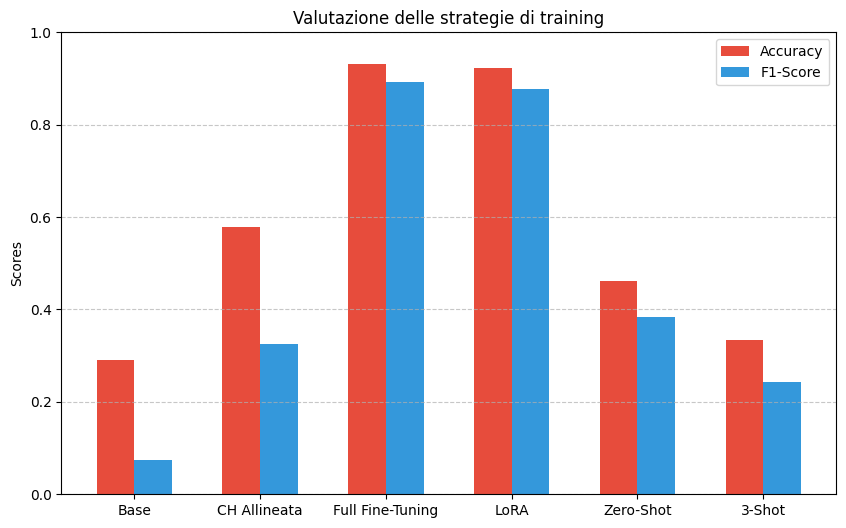

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Risultati
strategies = ['Base', 'CH Allineata', 'Full Fine-Tuning', 'LoRA', 'Zero-Shot', '3-Shot']
accuracies = [0.2905, 0.5795, 0.9310, 0.9235, 0.462500, 0.334667]
f1_scores =  [0.0750, 0.3250, 0.8926, 0.8777, 0.382864, 0.243692]

x = np.arange(len(strategies))
width = 0.30

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='#e74c3c')  # Rosso
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#3498db')  # Blu

ax.set_ylabel('Scores')
ax.set_title('Valutazione delle strategie di training')
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.set_ylim(0, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Analisi degli errori del miglior training

In [39]:
# Analisi degli errori
def analyze_errors(trainer, tokenizer, predictions_output, predictions, model_name, num_examples=20):

    labels = predictions_output.label_ids
    probs = torch.nn.functional.softmax(torch.tensor(predictions_output.predictions), dim=1).numpy()

    # Trova errori
    errors_idx = np.where(predictions != labels)[0]

    print(f"\n{'='*70}")
    print(f"ANALISI ERRORI - {model_name}")
    print(f"{'='*70}")
    print(f"Totale errori: {len(errors_idx)} su {len(labels)} ({len(errors_idx)/len(labels)*100:.2f}%)\n")

    # Testi originali
    original_test = dataset['validation']  # Dataset originale con testi

    label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

    # Ordina errori per confidenza (errori ad alta confidenza sono più interessanti)
    error_confidences = [probs[i][predictions[i]] for i in errors_idx]
    sorted_errors = sorted(zip(errors_idx, error_confidences), key=lambda x: x[1], reverse=True)

    # Analizza top errori
    print(f"TOP {num_examples} ERRORI PIÙ CONFIDENTI:\n")

    error_analysis = []
    for i, (idx, conf) in enumerate(sorted_errors[:num_examples]):
        idx = int(idx)

        text = original_test[idx]['text']
        true_label = label_names[labels[idx]]
        pred_label = label_names[predictions[idx]]

        print(f"{i+1}. Testo: \"{text}\"")
        print(f"   Vera etichetta: {true_label}")
        print(f"   Predizione: {pred_label} (confidenza: {conf:.4f})")
        print(f"   Probabilità: {dict(zip(label_names, probs[idx]))}")
        print()

        error_analysis.append({
            "text": text,
            "true_label": true_label,
            "predicted_label": pred_label,
            "confidence": float(conf),
            "probabilities": {name: float(prob) for name, prob in zip(label_names, probs[idx])}
        })

    # Salva analisi errori
    with open(f'{model_name.replace(" ", "_")}_error_analysis.json', 'w') as f:
        json.dump(error_analysis, f, indent=4, ensure_ascii=False)

    # Matrice di confusione degli errori più comuni
    from collections import Counter
    error_pairs = [(label_names[labels[i]], label_names[predictions[i]]) for i in errors_idx]
    most_common_errors = Counter(error_pairs).most_common(10)

    print(f"\nERRORI PIÙ COMUNI:")
    for (true_lbl, pred_lbl), count in most_common_errors:
        print(f"  {true_lbl} → {pred_lbl}: {count} volte")

    return error_analysis



CARICAMENTO BEST MODEL - Modello Fine-Tuned lr2e-05_bs16


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modello caricato da: /content/drive/MyDrive/RoBERTa-base/best_model
Numero classi: 6
Classi: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Test set: 2000 esempi

Trainer configurato

GENERAZIONE PREDIZIONI SUL TEST SET


Predizioni generate: 2000 esempi

GENERAZIONE CONFUSION MATRIX
Confusion matrix salvata in: /content/drive/MyDrive/RoBERTa-base/confusion_matrix_validation.png


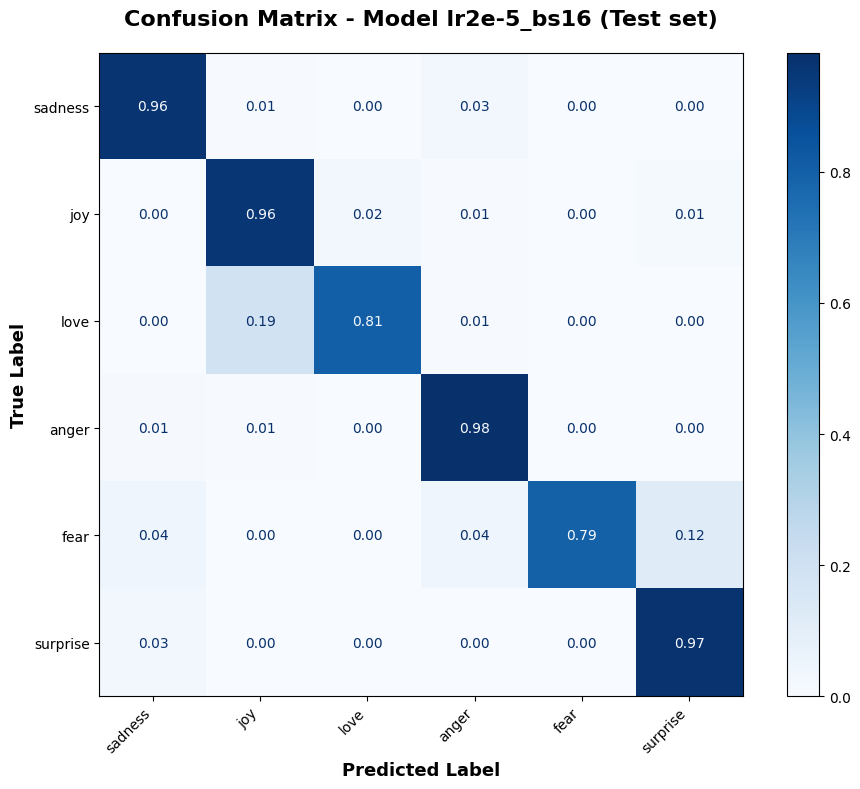


CONFUSION MATRIX - CONTEGGI ASSOLUTI
Confusion matrix (counts) salvata in: /content/drive/MyDrive/RoBERTa-base/confusion_matrix_counts.png


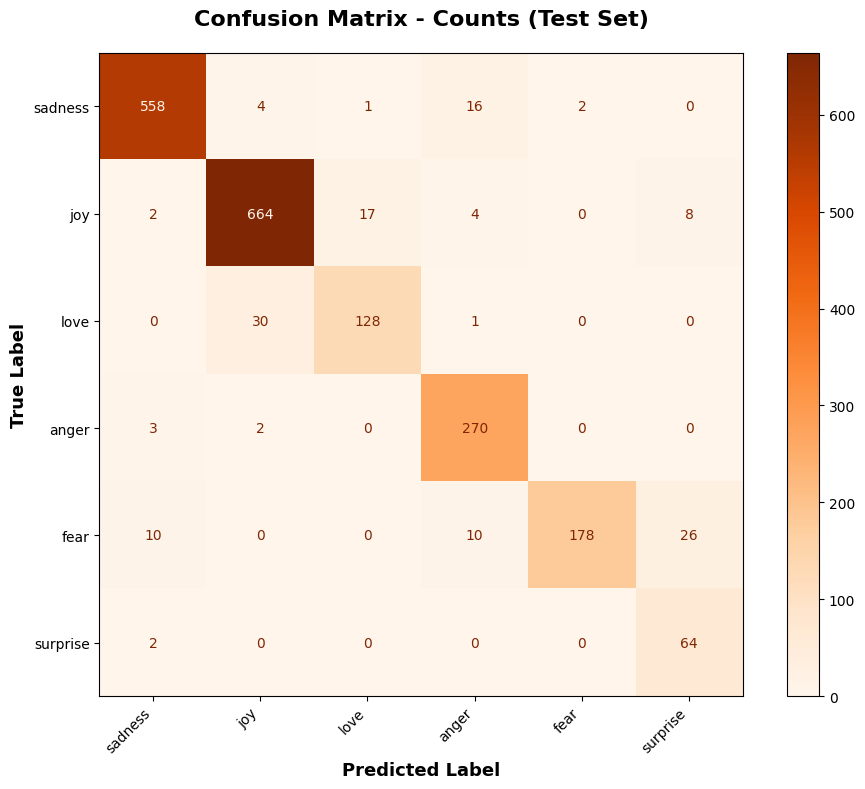


CLASSIFICATION REPORT PER CLASSE
              precision    recall  f1-score   support

     sadness     0.9704    0.9604    0.9654       581
         joy     0.9486    0.9554    0.9520       695
        love     0.8767    0.8050    0.8393       159
       anger     0.8970    0.9818    0.9375       275
        fear     0.9889    0.7946    0.8812       224
    surprise     0.6531    0.9697    0.7805        66

    accuracy                         0.9310      2000
   macro avg     0.8891    0.9112    0.8926      2000
weighted avg     0.9369    0.9310    0.9313      2000


ANALISI ERRORI - RoBERTa-base
Totale errori: 138 su 2000 (6.90%)

TOP 5 ERRORI PIÙ CONFIDENTI:

1. Testo: "i have a job where i am needed and where i am missed when i go away and its not just the things that i do that are missed but me as a person and that feels amazing"
   Vera etichetta: anger
   Predizione: joy (confidenza: 0.9997)
   Probabilità: {'sadness': np.float32(0.00010500895), 'joy': np.float32(0.99965453),

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments
)
from datasets import load_dataset
import torch
import json

# 1. CARICAMENTO DEL MODELLO MIGLIORE

print("="*60)
print("CARICAMENTO BEST MODEL - Modello Fine-Tuned lr2e-05_bs16")
print("="*60)

model_path = "/content/drive/MyDrive/RoBERTa-base/best_model"

model = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

print(f"Modello caricato da: {model_path}")
print(f"Numero classi: {model.config.num_labels}")

id2label = model.config.id2label
label2id = model.config.label2id

print(f"Classi: {list(id2label.values())}")

print(f"Test set: {len(tokenized_datasets['test'])} esempi")

# 2. CONFIGURAZIONE DEL TRAINER PER PREDIZIONE

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Training arguments (solo per evaluation)
training_args = TrainingArguments(
    output_dir="./tmp",
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    report_to="none"
)

# Crea Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator
)

print("\nTrainer configurato")


# 3. GENERAZIONE PREDIZIONI

print("\n" + "="*60)
print("GENERAZIONE PREDIZIONI SUL TEST SET")
print("="*60)

predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

print(f"Predizioni generate: {len(preds)} esempi")

# 4. CONFUSION MATRIX

print("\n" + "="*60)
print("GENERAZIONE CONFUSION MATRIX")
print("="*60)

# Calcola confusion matrix (normalizzata per riga = recall per classe)
cm = confusion_matrix(labels, preds, normalize='true')

# Crea figura
fig, ax = plt.subplots(figsize=(10, 8))

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(id2label.values())
)

disp.plot(cmap='Blues', ax=ax, values_format='.2f', colorbar=True)

# Personalizza
plt.title("Confusion Matrix - Model lr2e-5_bs16 (Test set)",
         fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Predicted Label", fontsize=13, fontweight='bold')
plt.ylabel("True Label", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Salva
save_path = "/content/drive/MyDrive/RoBERTa-base/confusion_matrix_validation.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix salvata in: {save_path}")
plt.show()

# 5. CONFUSION MATRIX NON NORMALIZZATA

print("\n" + "="*60)
print("CONFUSION MATRIX - CONTEGGI ASSOLUTI")
print("="*60)

# Confusion matrix con conteggi
cm_counts = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(10, 8))

disp_counts = ConfusionMatrixDisplay(
    confusion_matrix=cm_counts,
    display_labels=list(id2label.values())
)

disp_counts.plot(cmap='Oranges', ax=ax, values_format='d', colorbar=True)

plt.title("Confusion Matrix - Counts (Test Set)",
         fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Predicted Label", fontsize=13, fontweight='bold')
plt.ylabel("True Label", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

save_path_counts = "/content/drive/MyDrive/RoBERTa-base/confusion_matrix_counts.png"
plt.savefig(save_path_counts, dpi=300, bbox_inches='tight')
print(f"Confusion matrix (counts) salvata in: {save_path_counts}")
plt.show()

# 6. ANALISI PER CLASSE

from sklearn.metrics import classification_report

print("\n" + "="*60)
print("CLASSIFICATION REPORT PER CLASSE")
print("="*60)

report = classification_report(
    labels,
    preds,
    target_names=list(id2label.values()),
    digits=4
)
print(report)

# 7. ANALISI ERRORI

errors_roberta = analyze_errors(trainer, tokenizer, predictions, preds, "RoBERTa-base", num_examples=5)

print("\n" + "="*60)
print("ANALISI COMPLETATA")
print("="*60)
